#  WikiArt Artwork Classification Project

## Introduction

This notebook demonstrates a **Deep Learning pipeline** for classifying artworks from the **WikiArt dataset** using **Convolutional Neural Networks (CNNs)** and **Transfer Learning**. The main goal is to classify various **art styles** such as Impressionism, Cubism, and Baroque, with potential extension to artist recognition.  

---

## Project Objectives

- Train and evaluate at least **3 CNN architectures**:  
  - **VGG16**  
  - **ResNet50**  
  - **EfficientNet-B0**  

- Use **data augmentation** and **normalization** to improve generalization.  
- Split dataset into **80% train** and **20% test**.  
- Compare models based on **test accuracy** and **confusion matrices**.  
- Save trained models for reuse and deployment.

---

This notebook includes:  

1. **Data loading, augmentation, and normalization**  
2. **Training functions and model fine-tuning**  
3. **Evaluation and visualization (accuracy & confusion matrices)**  
4. **Saving trained models** for later use

---


###  Checking Available Dataset in `/kaggle/input`

In [2]:
import os

base_path = "/kaggle/input"
print(os.listdir(base_path))


['wikiart30k']


###  Setting the Dataset Path

In this cell, we define the path to our dataset inside the Kaggle environment.  
After confirming the dataset folder name from the previous step, we set:

```python
dataset_path = "/kaggle/input/wikiart30k/"


In [3]:
dataset_path = "/kaggle/input/wikiart30k/"
print(os.listdir(dataset_path))


['Pop_Art', 'Minimalism', 'Color_Field_Painting', 'Mannerism_Late_Renaissance', 'Symbolism', 'Impressionism', 'Contemporary_Realism', 'High_Renaissance', 'Fauvism', 'Rococo', 'Early_Renaissance', 'Naive_Art_Primitivism', 'Pointillism', 'Cubism', 'Synthetic_Cubism', 'Action_painting', 'Abstract_Expressionism', 'New_Realism', 'Baroque', 'Analytical_Cubism', 'wikiart_test.txt', 'Expressionism', 'Romanticism', 'Northern_Renaissance', 'Ukiyo_e', 'wikiart_train.txt', 'Post_Impressionism', 'Art_Nouveau_Modern', 'Realism']


###  Loading and Splitting the WikiArt Dataset

In this cell, we prepare the dataset for training and testing our CNN models.

#### 🔹 1. Import Required Libraries
We import:
- `torch` for tensor operations  
- `datasets` and `transforms` from `torchvision` to load and preprocess images  
- `DataLoader` to efficiently batch the data  

#### 🔹 2. Define Transformations
We apply the following preprocessing steps to all images:
- `Resize((224, 224))`: Ensures all images match the input size expected by CNNs like VGG16 and ResNet.
- `ToTensor()`: Converts images into PyTorch tensors.

#### 🔹 3. Load the WikiArt Dataset
We load the dataset using:
```python
full_dataset = datasets.ImageFolder(dataset_path, transform=transform)


In [4]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset_path = "/kaggle/input/wikiart30k/"

# Load full dataset
full_dataset = datasets.ImageFolder(dataset_path, transform=transform)

# Split 80/20
train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size

train_data, test_data = torch.utils.data.random_split(full_dataset, [train_size, test_size])

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

print("Train samples:", len(train_data))
print("Test samples:", len(test_data))
print("Classes:", full_dataset.classes)


Train samples: 24000
Test samples: 6000
Classes: ['Abstract_Expressionism', 'Action_painting', 'Analytical_Cubism', 'Art_Nouveau_Modern', 'Baroque', 'Color_Field_Painting', 'Contemporary_Realism', 'Cubism', 'Early_Renaissance', 'Expressionism', 'Fauvism', 'High_Renaissance', 'Impressionism', 'Mannerism_Late_Renaissance', 'Minimalism', 'Naive_Art_Primitivism', 'New_Realism', 'Northern_Renaissance', 'Pointillism', 'Pop_Art', 'Post_Impressionism', 'Realism', 'Rococo', 'Romanticism', 'Symbolism', 'Synthetic_Cubism', 'Ukiyo_e']


###  Data Augmentation & Normalization for WikiArt Dataset

This cell prepares the training and testing datasets with proper **data augmentation**, **normalization**, and **splitting**. These steps improve model generalization and ensure compatibility with pretrained CNN architectures such as VGG16, ResNet50, and EfficientNet.

---

## 🔹 1. Define Training Transformations (Data Augmentation)

We apply several augmentations to the training images to prevent overfitting and increase dataset variability:

- **Resize(224×224)** → required input size for most CNNs  
- **RandomHorizontalFlip()** → flips the image horizontally  
- **RandomRotation(10°)** → rotates image ±10 degrees  
- **ColorJitter()** → randomly changes brightness & contrast  
- **ToTensor()** → converts image to PyTorch tensor  
- **Normalize(mean, std)** → uses ImageNet statistics for pretrained models  

These augmentations help the model generalize better to unseen images.

---

## 🔹 2. Define Testing Transformations

For testing, we only apply:
- `Resize`
- `ToTensor`
- `Normalize`

⚠️ No augmentation should be applied during testing to ensure consistent evaluation.

---

## 🔹 3. Load the Dataset Using ImageFolder

We load all images from the dataset directory:
```python
full_dataset = datasets.ImageFolder(data_path, transform=train_transform)


In [5]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

data_path = "/kaggle/input/wikiart30k" 

full_dataset = datasets.ImageFolder(data_path, transform=train_transform)

train_size = int(0.8 * len(full_dataset))
test_size = len(full_dataset) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(full_dataset, [train_size, test_size])

# test set uses test_transform
test_dataset.dataset.transform = test_transform

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

num_classes = len(full_dataset.classes)
print("Classes:", full_dataset.classes)


Classes: ['Abstract_Expressionism', 'Action_painting', 'Analytical_Cubism', 'Art_Nouveau_Modern', 'Baroque', 'Color_Field_Painting', 'Contemporary_Realism', 'Cubism', 'Early_Renaissance', 'Expressionism', 'Fauvism', 'High_Renaissance', 'Impressionism', 'Mannerism_Late_Renaissance', 'Minimalism', 'Naive_Art_Primitivism', 'New_Realism', 'Northern_Renaissance', 'Pointillism', 'Pop_Art', 'Post_Impressionism', 'Realism', 'Rococo', 'Romanticism', 'Symbolism', 'Synthetic_Cubism', 'Ukiyo_e']


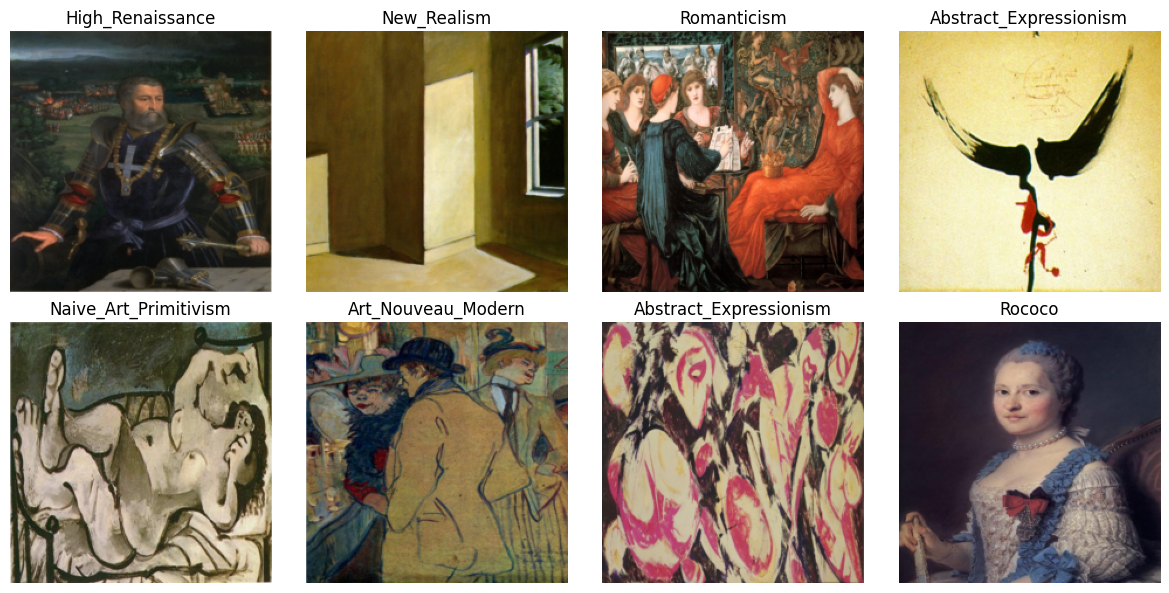

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img):
    img = img.numpy().transpose((1, 2, 0))
    
    # Undo normalization
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    plt.axis('off')

# Show a batch of samples
images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i+1)
    imshow(images[i])
    plt.title(full_dataset.classes[labels[i]])
plt.tight_layout()
plt.show()


###  Training Function for CNN Models (`train_model`)

This cell defines a reusable training function that works for any CNN architecture  
(e.g., **VGG16 – ResNet50 – EfficientNet**).

---

## 🔹 What the Function Does

### 1. **Device Setup**
Automatically selects:
- **GPU (CUDA)** if available  
- Otherwise falls back to **CPU**

```python
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [8]:
def train_model(model, train_loader, test_loader, epochs=3):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss/len(train_loader):.4f}")

    # Evaluation
    model.eval()
    correct, total = 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs,1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = correct/total
    print(f"Test Accuracy: {acc:.2f}")
    return model, acc, all_labels, all_preds


###  Training VGG16 on WikiArt Dataset

This cell fine-tunes a **pretrained VGG16** model for the WikiArt classification task.




In [22]:
vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
vgg.classifier[6] = nn.Linear(4096, num_classes)

vgg_model, vgg_acc, vgg_labels, vgg_preds = train_model(vgg, train_loader, test_loader, epochs=10)
torch.save(vgg_model.state_dict(), "vgg16_wikiart.pth")


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:02<00:00, 209MB/s]  


Epoch 1/10, Loss: 2.0952
Epoch 2/10, Loss: 1.6394
Epoch 3/10, Loss: 1.3296
Epoch 4/10, Loss: 0.9761
Epoch 5/10, Loss: 0.6343
Epoch 6/10, Loss: 0.3958
Epoch 7/10, Loss: 0.2816
Epoch 8/10, Loss: 0.2118
Epoch 9/10, Loss: 0.1736
Epoch 10/10, Loss: 0.1768
Test Accuracy: 0.49


### 🔴 Training ResNet50 on WikiArt Dataset

This cell fine-tunes a **pretrained ResNet50** model for the WikiArt classification task.


In [23]:
resnet = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)

resnet_model, resnet_acc, res_labels, res_preds = train_model(resnet, train_loader, test_loader, epochs=3)
torch.save(resnet_model.state_dict(), "resnet50_wikiart.pth")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 183MB/s] 


Epoch 1/3, Loss: 1.7927
Epoch 2/3, Loss: 1.1210
Epoch 3/3, Loss: 0.6859
Test Accuracy: 0.58


### 🟢 Training EfficientNet-B0 on WikiArt Dataset

This cell fine-tunes a **pretrained EfficientNet-B0** model for the WikiArt classification task.

---

In [11]:
effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
effnet.classifier[1] = nn.Linear(effnet.classifier[1].in_features, num_classes)

eff_model, eff_acc, eff_labels, eff_preds = train_model(effnet, train_loader, test_loader, epochs=10)
torch.save(eff_model.state_dict(), "efficientnet_b0_wikiart.pth")


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth
100%|██████████| 20.5M/20.5M [00:00<00:00, 144MB/s] 


Epoch 1/10, Loss: 1.9890
Epoch 2/10, Loss: 1.3911
Epoch 3/10, Loss: 1.1375
Epoch 4/10, Loss: 0.9074
Epoch 5/10, Loss: 0.7298
Epoch 6/10, Loss: 0.5788
Epoch 7/10, Loss: 0.4640
Epoch 8/10, Loss: 0.3666
Epoch 9/10, Loss: 0.3071
Epoch 10/10, Loss: 0.2575
Test Accuracy: 0.57


###  Model Evaluation & Confusion Matrices

This cell evaluates all trained CNN models on the test set and visualizes their performance.

---

Classes: ['Abstract_Expressionism', 'Action_painting', 'Analytical_Cubism', 'Art_Nouveau_Modern', 'Baroque', 'Color_Field_Painting', 'Contemporary_Realism', 'Cubism', 'Early_Renaissance', 'Expressionism', 'Fauvism', 'High_Renaissance', 'Impressionism', 'Mannerism_Late_Renaissance', 'Minimalism', 'Naive_Art_Primitivism', 'New_Realism', 'Northern_Renaissance', 'Pointillism', 'Pop_Art', 'Post_Impressionism', 'Realism', 'Rococo', 'Romanticism', 'Symbolism', 'Synthetic_Cubism', 'Ukiyo_e']
===== VGG16 Evaluation =====
Test Accuracy: 0.4912


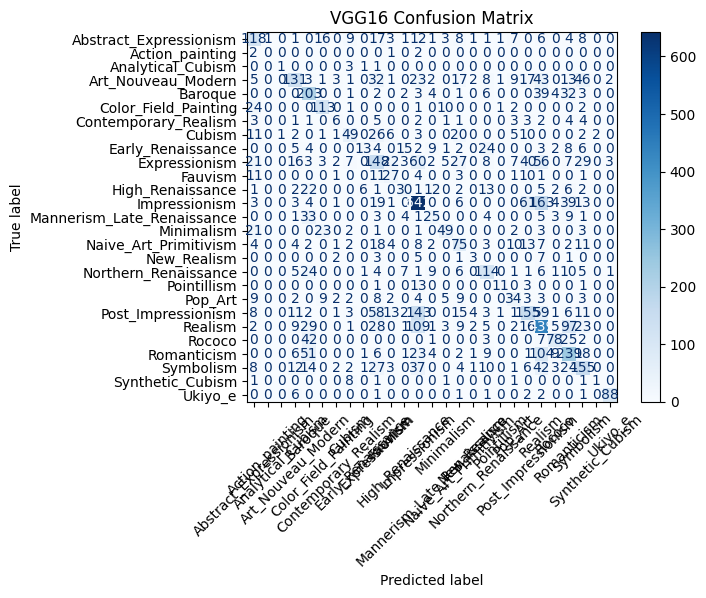

===== ResNet50 Evaluation =====
Test Accuracy: 0.5797


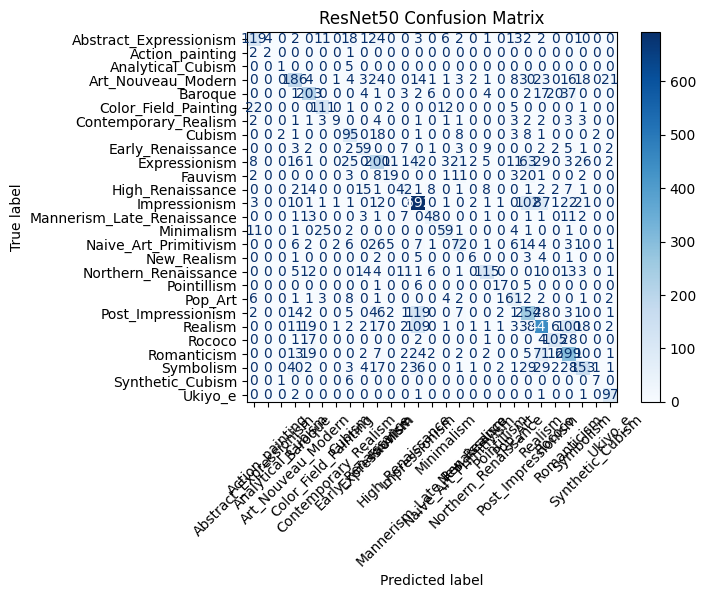

===== EfficientNet-B0 Evaluation =====
Test Accuracy: 0.5662


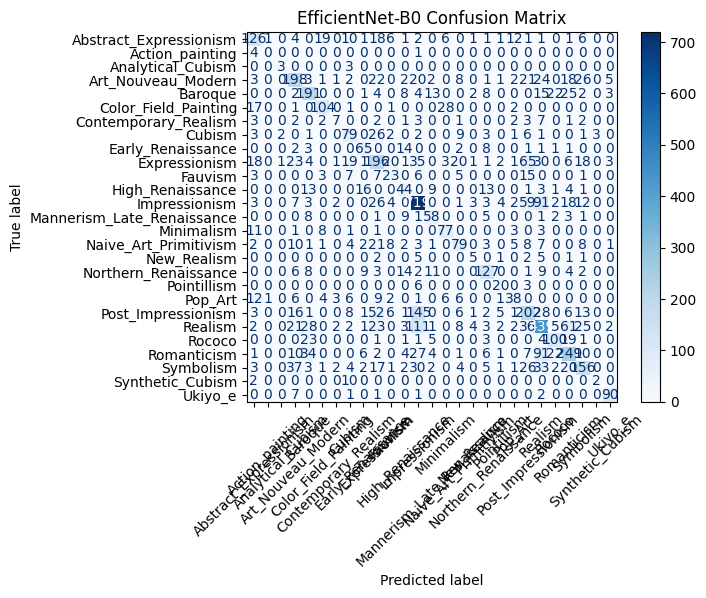

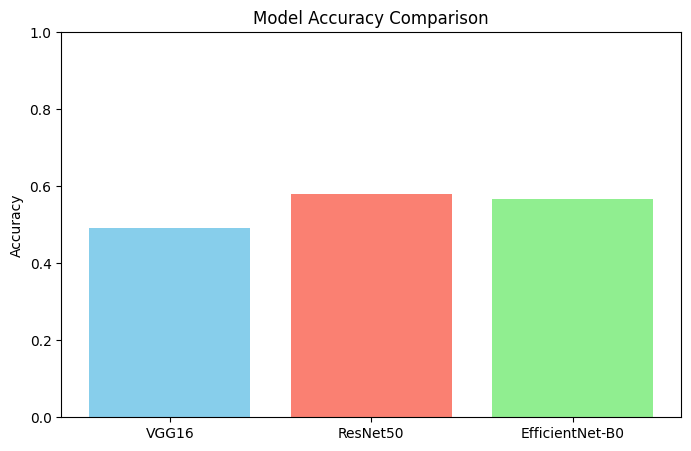

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, accuracy_score
import torch


classes = full_dataset.classes
print("Classes:", classes)

# Evaluation function
def evaluate_model(model, test_loader, device):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    acc = accuracy_score(all_labels, all_preds)
    print(f"Test Accuracy: {acc:.4f}")
    return all_labels, all_preds, acc

# Plot Confusion Matrix
def plot_conf_matrix(labels, preds, classes, title="Confusion Matrix"):
    cm = confusion_matrix(labels, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    disp.plot(xticks_rotation=45, cmap=plt.cm.Blues)
    plt.title(title)
    plt.show()

# =============================
# Evaluate & plot for all models
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("===== VGG16 Evaluation =====")
vgg_labels, vgg_preds, vgg_acc = evaluate_model(vgg_model, test_loader, device)
plot_conf_matrix(vgg_labels, vgg_preds, classes, title="VGG16 Confusion Matrix")

print("===== ResNet50 Evaluation =====")
res_labels, res_preds, res_acc = evaluate_model(resnet_model, test_loader, device)
plot_conf_matrix(res_labels, res_preds, classes, title="ResNet50 Confusion Matrix")

print("===== EfficientNet-B0 Evaluation =====")
eff_labels, eff_preds, eff_acc = evaluate_model(eff_model, test_loader, device)
plot_conf_matrix(eff_labels, eff_preds, classes, title="EfficientNet-B0 Confusion Matrix")

# Comparison Plot
model_names = ["VGG16", "ResNet50", "EfficientNet-B0"]
accuracies = [vgg_acc, res_acc, eff_acc]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies, color=['skyblue','salmon','lightgreen'])
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()


### Crate Models Folder

In [25]:
import os

save_path = "/kaggle/working/models"
os.makedirs(save_path, exist_ok=True)

print("Saving folder:", save_path)


Saving folder: /kaggle/working/models


###  Save Class Names to JSON

In [27]:
import json
import os

save_path = "./"  
os.makedirs(save_path, exist_ok=True)

classes_path = f"{save_path}/classes.json"


with open(classes_path, "w") as f:
    json.dump(classes, f, indent=4)

print("Saved classes to:", classes_path)


Saved classes to: .//classes.json


###  Save Trained Model (Weights & Full Model)

In [31]:
import torch

def save_model(model, model_name, save_path, classes=None):
    # 1) Save state_dict (weights only)
    weights_path = f"{save_path}/{model_name}_weights.pth"
    torch.save(model.state_dict(), weights_path)

    # 2) Save full model
    full_model_path = f"{save_path}/{model_name}_full.pkl"
    torch.save(model, full_model_path)

    print(f"Saved: {weights_path}")
    print(f"Saved: {full_model_path}")


###  Save VGG16 Model

In [32]:
save_model(vgg_model, "vgg16", save_path)


Saved: .//vgg16_weights.pth
Saved: .//vgg16_full.pkl


###  Save ResNET Model

In [33]:
save_model(resnet_model, "resnet50", save_path)


Saved: .//resnet50_weights.pth
Saved: .//resnet50_full.pkl


###  Save EfficientNet Model

In [35]:
save_model(eff_model, "efficientnet_b0", save_path)


Saved: .//efficientnet_b0_weights.pth
Saved: .//efficientnet_b0_full.pkl
